# CS 5480: Deep Learning — Assignment 4

**Total:** 100 points (+bonus)  
**Due:** See Canvas  

---

## Overview

In Assignment 3 you saw that deep networks fail in predictable ways — gradients vanish across layers, activations explode, and nothing trains without careful engineering. You fixed those failures one tool at a time.

This assignment runs the same playbook, but the failure now happens across **time** instead of across **layers**. You will start with a broken vanilla RNN — one that cannot learn long-range dependencies — and fix it step by step: first with attention as a soft alignment mechanism, then with the Transformer architecture that replaces recurrence entirely, and finally with BERT, which shows what happens when you scale that architecture with massive pretraining.

By the end, you will have implemented the core of modern NLP from first principles and trained it on real data.

---

## Datasets

- **Part 1:** Synthetic long-range dependency task (provided)
- **Part 2:** Multi30k English→German translation
- **Parts 3 & 4:** SST-2 binary sentiment classification

---

## Tools by Part

| Part | Allowed Libraries |
|------|------------------|
| 1 — RNN Diagnosis | NumPy only (model provided) |
| 2 — Bahdanau Attention | PyTorch tensors (GPU encouraged) |
| 3 — Transformer from Scratch | PyTorch tensors, no `nn.MultiheadAttention` or `nn.TransformerEncoder` |
| 4 — BERT Fine-tuning | HuggingFace Transformers + PyTorch |

---

## Submission Requirements

- Submit a single ZIP file named `LastName_FirstName_Assignment4.zip` containing your completed `.ipynb`
- The notebook must run **top-to-bottom without errors** on Colab (Runtime → Run all)
- All plots must be generated by the notebook — no pasted images
- Include **markdown analysis cells** after each sub-part as instructed
- Set random seeds at the top of every relevant cell — results must be reproducible

---

## Academic Integrity

You may discuss high-level concepts with classmates but all submitted work must be your own. You may not share code or written analysis. You may use AI tools for clarification and debugging but not to generate final solutions. If AI tools are used, include a brief acknowledgment describing how.

---

## Global Setup

Run this cell first. It installs dependencies, sets seeds, and configures the device.

In [2]:
# Install required packages
# !pip install torch torchtext torchdata sacrebleu datasets transformers sentencepiece -q

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import math
import random
import time
from collections import defaultdict

# Global seeds — do not change
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

# Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cpu


---
# Part 1: Diagnosing a Broken RNN (15 points)

| Sub-part | Description | Points |
|----------|-------------|--------|
| 1(b) | Gradient flow visualization | 5 |
| 1(c) | Spectral analysis | 5 |
| 1 Analysis | Written analysis | 5 |
| **Total** | | **15** |

In Assignment 3 you diagnosed a broken deep MLP: gradients vanished across **layers**. Here the failure is different — gradients vanish across **time**. A vanilla RNN theoretically can propagate information from timestep 1 to timestep T, but in practice the signal decays exponentially as it travels backward through the unrolled computation graph.

---

### Background: Backpropagation Through Time (BPTT)

A vanilla RNN computes:
$$h_t = \\tanh(W_{hh} h_{t-1} + W_{xh} x_t + b_h)$$

During backprop, the gradient of the loss with respect to $h_1$ must flow through all intermediate hidden states:
$$\\frac{\\partial L}{\\partial h_1} = \\frac{\\partial L}{\\partial h_T} \\prod_{t=2}^{T} \\frac{\\partial h_t}{\\partial h_{t-1}}$$

Each Jacobian $\\frac{\\partial h_t}{\\partial h_{t-1}} = \\text{diag}(1 - h_t^2) \\cdot W_{hh}$ involves both the weight matrix and the tanh derivative. When the spectral radius of this product is less than 1, gradients vanish. When it exceeds 1, they explode.


### Part 1(a): Provided Vanilla RNN (0 points — read carefully)

The cell below provides a complete vanilla RNN implementation in NumPy. **Do not modify this class.** Study the forward and backward methods — you will need to understand them to answer the analysis questions.

In [3]:
class VanillaRNN:
    """
    Vanilla RNN implemented in NumPy.
    Input:  sequences of shape (T, input_size)
    Hidden: h_t = tanh(W_hh @ h_{t-1} + W_xh @ x_t + b_h)
    Output: y_t = W_hy @ h_t + b_y  (only at final timestep for classification)
    """
    def __init__(self, input_size, hidden_size, output_size, seed=42):
        np.random.seed(seed)
        scale = 0.01
        self.W_xh = np.random.randn(hidden_size, input_size)  * scale
        self.W_hh = np.random.randn(hidden_size, hidden_size) * scale
        self.b_h  = np.zeros(hidden_size)
        self.W_hy = np.random.randn(output_size, hidden_size) * scale
        self.b_y  = np.zeros(output_size)
        self.hidden_size = hidden_size

    def forward(self, xs):
        """
        xs: list of T input vectors, each of shape (input_size,)
        Returns: output logits (output_size,), cache of all hidden states
        """
        T = len(xs)
        h = np.zeros(self.hidden_size)
        self.cache = {'xs': xs, 'hs': [np.zeros(self.hidden_size)], 'zs': []}

        for t in range(T):
            z = self.W_xh @ xs[t] + self.W_hh @ h + self.b_h
            h = np.tanh(z)
            self.cache['zs'].append(z)
            self.cache['hs'].append(h)

        logits = self.W_hy @ h + self.b_y
        return logits

    def backward(self, d_logits):
        """
        d_logits: gradient of loss w.r.t. output logits, shape (output_size,)
        Returns: dict of gradients, and gradient norms at each timestep
        """
        xs  = self.cache['xs']
        hs  = self.cache['hs']
        zs  = self.cache['zs']
        T   = len(xs)

        dW_xh = np.zeros_like(self.W_xh)
        dW_hh = np.zeros_like(self.W_hh)
        db_h  = np.zeros_like(self.b_h)
        dW_hy = np.zeros_like(self.W_hy)
        db_y  = np.zeros_like(self.b_y)

        # Gradient from output layer
        dW_hy += np.outer(d_logits, hs[-1])
        db_y  += d_logits
        dh     = self.W_hy.T @ d_logits

        # Store gradient norms as we BPTT through time
        grad_norms = []

        for t in reversed(range(T)):
            # tanh derivative
            dtanh = (1 - np.tanh(zs[t])**2) * dh

            dW_xh += np.outer(dtanh, xs[t])
            dW_hh += np.outer(dtanh, hs[t])
            db_h  += dtanh

            # Record norm of gradient w.r.t. hidden state at this timestep
            grad_norms.insert(0, np.linalg.norm(dh))

            # Propagate gradient back one more step
            dh = self.W_hh.T @ dtanh

        grads = {
            'W_xh': dW_xh, 'W_hh': dW_hh, 'b_h': db_h,
            'W_hy': dW_hy, 'b_y':  db_y
        }
        return grads, grad_norms


def generate_long_range_task(T, n_samples, seed=42):
    """
    Synthetic long-range dependency task.
    Input: binary sequence of length T
    Target: the value of the FIRST element in the sequence
    A network must remember information from timestep 0 all the way to timestep T.
    """
    np.random.seed(seed)
    X = np.random.randint(0, 2, size=(n_samples, T)).astype(float)
    y = X[:, 0].astype(int)  # target is always the first element
    return X, y


print('VanillaRNN and data generator defined.')
print('Task: given a binary sequence of length T, predict the FIRST element.')
print('This forces the network to maintain information across all T timesteps.')

VanillaRNN and data generator defined.
Task: given a binary sequence of length T, predict the FIRST element.
This forces the network to maintain information across all T timesteps.


### Part 1(b): Gradient Flow Visualization (5 points)

**Your task:** Run the diagnostic below and produce the required plots.

**Step 1:** For sequence lengths T ∈ {10, 25, 50}, instantiate a fresh `VanillaRNN(input_size=1, hidden_size=64, output_size=2)`. Run a single forward pass on one training example, compute a dummy loss (cross-entropy), and run the backward pass. Plot the gradient norm at each timestep on a single figure with three curves (one per T), x-axis = timestep (from 1 to T), y-axis = gradient norm.

**Step 2:** For T=50, train the RNN for 200 epochs using SGD (lr=0.01). After training, rerun the backward pass and plot the gradient norms at initialization vs. after training on the same figure.

**Step 3:** For T=50, plot the training loss and accuracy curves over 200 epochs.


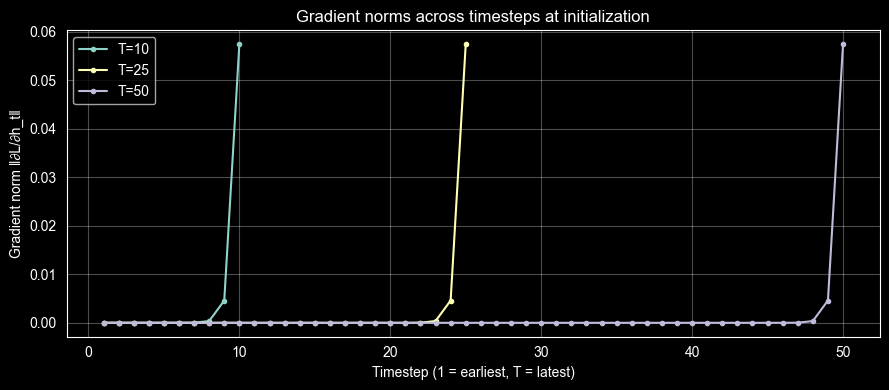

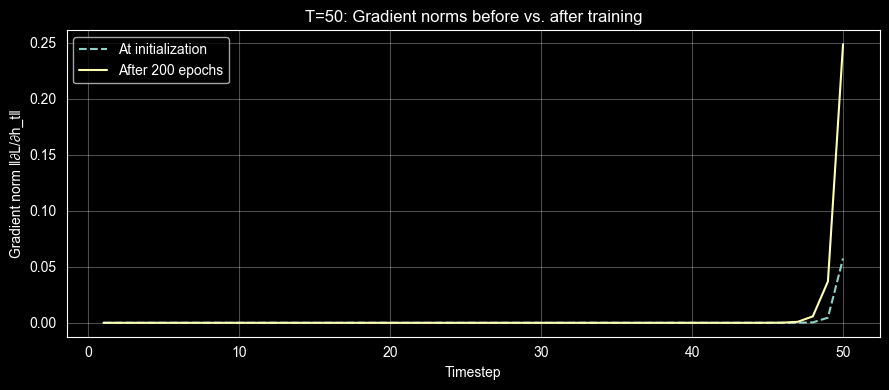

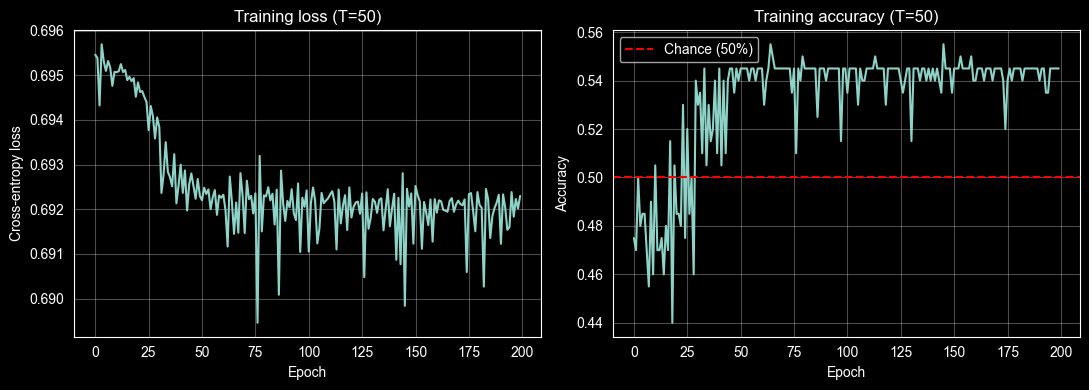

Final loss: 0.6923 | Final accuracy: 0.5450


In [4]:
np.random.seed(SEED)

# ── Helper: softmax and cross-entropy ────────────────────────────────────────
def softmax(x):
    e = np.exp(x - x.max())
    return e / e.sum()

def cross_entropy(logits, label):
    probs = softmax(logits)
    return -np.log(probs[label] + 1e-9)

def d_cross_entropy(logits, label):
    probs = softmax(logits)
    probs[label] -= 1
    return probs


# ── Step 1: Gradient norms vs. timestep for T ∈ {10, 25, 50} ────────────────
fig, ax = plt.subplots(figsize=(9, 4))

for T in [10, 25, 50]:
    X, y = generate_long_range_task(T, n_samples=100)
    rnn = VanillaRNN(input_size=1, hidden_size=64, output_size=2)

    # Single example forward + backward
    xs = [X[0, t:t+1] for t in range(T)]
    logits = rnn.forward(xs)
    d_logits = d_cross_entropy(logits, int(y[0]))
    _, grad_norms = rnn.backward(d_logits)

    timesteps = list(range(1, T + 1))
    ax.plot(timesteps, grad_norms, marker='o', markersize=3, label=f'T={T}')

ax.set_xlabel('Timestep (1 = earliest, T = latest)')
ax.set_ylabel('Gradient norm ‖∂L/∂h_t‖')
ax.set_title('Gradient norms across timesteps at initialization')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ── Step 2: Gradient norms before vs. after training (T=50) ──────────────────
T = 50
X, y = generate_long_range_task(T, n_samples=200)
rnn50 = VanillaRNN(input_size=1, hidden_size=64, output_size=2)

# Record norms at initialization
xs0 = [X[0, t:t+1] for t in range(T)]
logits0 = rnn50.forward(xs0)
_, norms_init = rnn50.backward(d_cross_entropy(logits0, int(y[0])))

# Training loop
lr = 0.01
n_epochs = 200
losses, accs = [], []

param_keys = ['W_xh', 'W_hh', 'b_h', 'W_hy', 'b_y']

for epoch in range(n_epochs):
    epoch_loss, correct = 0.0, 0
    idx = np.random.permutation(len(X))
    for i in idx:
        xs_i = [X[i, t:t+1] for t in range(T)]
        logits_i = rnn50.forward(xs_i)
        epoch_loss += cross_entropy(logits_i, int(y[i]))
        correct    += int(np.argmax(softmax(logits_i)) == int(y[i]))
        grads, _ = rnn50.backward(d_cross_entropy(logits_i, int(y[i])))
        for key in param_keys:
            getattr(rnn50, key)[:] -= lr * grads[key]
    losses.append(epoch_loss / len(X))
    accs.append(correct / len(X))

# Record norms after training
logits_f = rnn50.forward(xs0)
_, norms_trained = rnn50.backward(d_cross_entropy(logits_f, int(y[0])))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, T+1), norms_init,    label='At initialization', linestyle='--')
ax.plot(range(1, T+1), norms_trained, label='After 200 epochs')
ax.set_xlabel('Timestep')
ax.set_ylabel('Gradient norm ‖∂L/∂h_t‖')
ax.set_title('T=50: Gradient norms before vs. after training')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ── Step 3: Training curves ───────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(losses)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Cross-entropy loss')
ax1.set_title('Training loss (T=50)')
ax1.grid(True, alpha=0.3)

ax2.plot(accs)
ax2.axhline(0.5, color='red', linestyle='--', label='Chance (50%)')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_title('Training accuracy (T=50)')
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Final loss: {losses[-1]:.4f} | Final accuracy: {accs[-1]:.4f}')

### Part 1(c): Spectral Analysis (5 points)

The gradient norm plot shows *what* happens. This task asks you to show *why* — directly from the weight matrix.

**Your task:** At initialization and after training, compute the spectral radius (largest singular value) of `W_hh`. Plot the spectral radius at each epoch during training on its own figure. Then answer the analysis questions below.


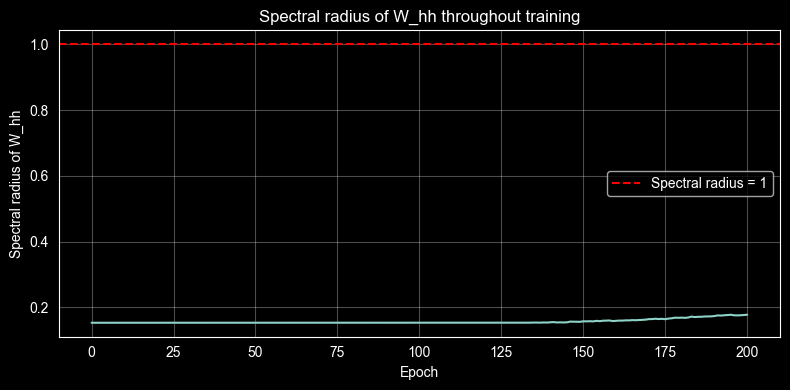

Spectral radius at init:         0.1535
Spectral radius after training:  0.1779


In [5]:
np.random.seed(SEED)

# ── Track spectral radius of W_hh throughout training ────────────────────────
T = 50
X, y = generate_long_range_task(T, n_samples=200)
rnn_spec = VanillaRNN(input_size=1, hidden_size=64, output_size=2)

lr = 0.01
n_epochs = 200
spectral_radii = []

# Record spectral radius at initialization
spectral_radii.append(np.linalg.svd(rnn_spec.W_hh, compute_uv=False)[0])

for epoch in range(n_epochs):
    idx = np.random.permutation(len(X))
    for i in idx:
        xs_i = [X[i, t:t+1] for t in range(T)]
        logits_i = rnn_spec.forward(xs_i)
        grads, _ = rnn_spec.backward(d_cross_entropy(logits_i, int(y[i])))
        for key in param_keys:
            getattr(rnn_spec, key)[:] -= lr * grads[key]
    spectral_radii.append(np.linalg.svd(rnn_spec.W_hh, compute_uv=False)[0])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(spectral_radii)
ax.axhline(1.0, color='red', linestyle='--', label='Spectral radius = 1')
ax.set_xlabel('Epoch')
ax.set_ylabel('Spectral radius of W_hh')
ax.set_title('Spectral radius of W_hh throughout training')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Spectral radius at init:         {spectral_radii[0]:.4f}')
print(f'Spectral radius after training:  {spectral_radii[-1]:.4f}')

### Part 1(d): Analysis (5 points)

Answer **all** of the following in the markdown cell below. **200–300 words total.** Each question is worth 1 point.

1. Look at your gradient norm plots from Part 1(b). What pattern do you observe across timesteps, and how does the severity change with sequence length T? Name the phenomenon you are observing.

2. In Assignment 3 you observed vanishing gradients **across layers**. Here you observe them **across time**. What is the fundamental mathematical cause common to both? Where does the repeated matrix product appear in each case?

3. Look at the spectral radius plot from Part 1(c). How does the spectral radius of $W_{hh}$ relate to whether gradients vanish or explode? What does a spectral radius below 1 vs. above 1 imply?

4. The training accuracy on the T=50 task likely stayed near 50% (chance). Why? What would need to change architecturally for the network to solve this task?

5. Without implementing one, explain in 2–3 sentences what architectural feature of the LSTM prevents the gradient from vanishing across long sequences.


1. The gradient norms are high at the final timesteps, and then as they move toward earlier timesteps they rapidly fall to 0. With sequence length T, the effect becomes more extreme. For example, at T=50, practically all timesteps from 1 to around 48 have gradient norms that are practically 0, if not literally 0. This is a prime case of the vanishing gradient problem across time, where learning signals vanish and become indistinguishable from 0 as they propagate back to earlier inputs.
2. The fundamental mathematical cause of the vanishing gradient problem across layers and across time is the multiplication of gradients by weight matrices. In deep networks, gradients are multiplied across layers using the chain rule, and in RNNs, they're multiplied across timesteps by repeatedly applying the recurrent matrix W_hh. In both across time and across layers, when the matrix has singular values less than 1 the gradient will shrink exponentially, becoming indistinguishable from 0 and vanishing.
3. The spectral radius of W_hh controls how signals evolve over time. We observe it starts at 0.1535, and increases to only 0.1779. Since it stays far below 1, repeatedly multiplying with it causes variants to shrink significantly, vanishing to 0. If the spectral radius were greater than 1, the gradients would grow and potentially explode.
4. The reason why T=50's accuracy was only 54.5%, and thus practically random guessing, was because the network was not able to learn anything over 50 timesteps. Remember, the gradient vanishes at around the 48th timestep (2 away from T=50), so the model ignores early inputs. To solve this task, the network would need a pathway for gradient flow to preserve the gradient information across time.
5. LSTMs introduce a cell state that acts as a way for information to flow across timesteps. This prevents gradients from vanishing to near-zero/zero, and would allow the model to learn long-range dependencies.

---
# Part 2: Bahdanau Attention (25 points)

| Sub-part | Description | Points |
|----------|-------------|--------|
| 2(c) | Implement Attention + Decoder | 12 |
| 2(d) | Training, BLEU evaluation, heatmaps | 8 |
| 2 Analysis | Written analysis | 5 |
| **Total** | | **25** |

The vanilla RNN’s failure on long sequences has a clear cause: information must pass through every hidden state between the source and the target, and the gradient signal decays exponentially along that path. Attention is a direct fix — instead of forcing all information through a single bottleneck, it lets the decoder **directly access** any encoder hidden state at each decoding step, weighted by relevance.

This part implements Bahdanau (additive) attention inside a GRU-based encoder-decoder trained on Multi30k English→German translation.

---

### Background: Bahdanau Attention

At each decoding timestep $t$, the attention mechanism computes:

$$e_{ti} = v^\top \tanh(W_a s_{t-1} + U_a h_i)$$


$$\alpha_{ti} = \frac{\exp(e_{ti})}{\sum_j \exp(e_{tj})}$$


$$c_t = \sum_i \alpha_{ti} h_i$$

where $s_{t-1}$ is the decoder's previous hidden state, $h_i$ are the encoder hidden states, $\alpha_{ti}$ are the attention weights (a probability distribution over source positions), and $c_t$ is the context vector used alongside the decoder input to compute the next hidden state and output.


### Part 2(a): Data Loading (0 points — provided)

Run the cell below to load and preprocess Multi30k. Study the output so you understand the vocabulary and tensor shapes before you start implementing.

In [1]:
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset
from collections import Counter

# ── Load Multi30k ─────────────────────────────────────────────────────────────
dataset = load_dataset('bentrevett/multi30k')
train_data = dataset['train']
val_data   = dataset['validation']
test_data  = dataset['test']

print(f'Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}')
print('Example:', train_data[0])

# ── Simple whitespace tokenizer ───────────────────────────────────────────────
def tokenize(text):
    return text.lower().split()

# ── Build vocabularies ────────────────────────────────────────────────────────
PAD_TOKEN = '<pad>'
SOS_TOKEN = '<sos>'
EOS_TOKEN = '<eos>'
UNK_TOKEN = '<unk>'
SPECIALS  = [PAD_TOKEN, SOS_TOKEN, EOS_TOKEN, UNK_TOKEN]

def build_vocab(data, lang, min_freq=2):
    counter = Counter()
    for example in data:
        counter.update(tokenize(example[lang]))
    vocab = {tok: idx for idx, tok in enumerate(SPECIALS)}
    for tok, freq in counter.items():
        if freq >= min_freq and tok not in vocab:
            vocab[tok] = len(vocab)
    return vocab

src_vocab = build_vocab(train_data, 'en')
tgt_vocab = build_vocab(train_data, 'de')
src_idx2tok = {v: k for k, v in src_vocab.items()}
tgt_idx2tok = {v: k for k, v in tgt_vocab.items()}

PAD_IDX = src_vocab[PAD_TOKEN]
SOS_IDX = tgt_vocab[SOS_TOKEN]
EOS_IDX = tgt_vocab[EOS_TOKEN]
UNK_IDX = src_vocab[UNK_TOKEN]

print(f'Source vocab size: {len(src_vocab)}')
print(f'Target vocab size: {len(tgt_vocab)}')

# ── Dataset class ─────────────────────────────────────────────────────────────
def encode(tokens, vocab):
    return [vocab.get(t, UNK_IDX) for t in tokens]

class TranslationDataset(Dataset):
    def __init__(self, data):
        self.pairs = []
        for ex in data:
            src = encode(tokenize(ex['en']), src_vocab)
            tgt = encode(tokenize(ex['de']), tgt_vocab)
            self.pairs.append((src, tgt))

    def __len__(self):  return len(self.pairs)
    def __getitem__(self, i): return self.pairs[i]

def collate_fn(batch):
    srcs, tgts = zip(*batch)
    max_src = max(len(s) for s in srcs)
    max_tgt = max(len(t) for t in tgts)
    src_pad = torch.tensor([s + [PAD_IDX]*(max_src-len(s)) for s in srcs])
    tgt_pad = torch.tensor([[SOS_IDX]+t+[EOS_IDX] + [PAD_IDX]*(max_tgt-len(t)) for t in tgts])
    return src_pad, tgt_pad

BATCH_SIZE = 128
train_loader = DataLoader(TranslationDataset(train_data), batch_size=BATCH_SIZE,
                          shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(TranslationDataset(val_data),   batch_size=BATCH_SIZE,
                          shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(TranslationDataset(test_data),  batch_size=BATCH_SIZE,
                          shuffle=False, collate_fn=collate_fn)

print('Data loaders ready.')

README.md: 0.00B [00:00, ?B/s]

train.jsonl: 0.00B [00:00, ?B/s]

val.jsonl: 0.00B [00:00, ?B/s]

test.jsonl: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/29000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1014 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Train: 29000 | Val: 1014 | Test: 1000
Example: {'en': 'Two young, White males are outside near many bushes.', 'de': 'Zwei junge weiße Männer sind im Freien in der Nähe vieler Büsche.'}
Source vocab size: 7704
Target vocab size: 9597
Data loaders ready.


### Part 2(b): Provided GRU Encoder (0 points — read carefully)

The encoder below is provided. You will use its outputs as inputs to your attention mechanism. **Do not modify this class.**

In [ ]:
class Encoder(nn.Module):
    """
    Bidirectional GRU encoder.
    Returns:
        encoder_outputs: (batch, src_len, 2*hidden_size)  — all hidden states
        hidden:          (batch, hidden_size)              — final hidden state
                         (concatenation of forward and backward final states,
                          then projected down to hidden_size)
    """
    def __init__(self, vocab_size, embed_size, hidden_size, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=PAD_IDX)
        self.rnn       = nn.GRU(embed_size, hidden_size, bidirectional=True, batch_first=True)
        self.fc        = nn.Linear(hidden_size * 2, hidden_size)
        self.dropout   = nn.Dropout(dropout)

    def forward(self, src):
        # src: (batch, src_len)
        embedded = self.dropout(self.embedding(src))          # (batch, src_len, embed)
        outputs, hidden = self.rnn(embedded)                  # outputs: (batch, src_len, 2H)
        # Combine forward and backward final hidden states
        hidden = torch.tanh(self.fc(
            torch.cat([hidden[-2], hidden[-1]], dim=1)        # (batch, 2H)
        ))                                                    # (batch, H)
        return outputs, hidden

print('Encoder defined.')

### Part 2(c): Implement Bahdanau Attention and Decoder (12 points)

**Your task:** Implement the `Attention` module and the `Decoder` class.

**`Attention` module** must:
- Compute alignment scores between the decoder hidden state and each encoder hidden state
- Return attention weights $\\alpha$ (a probability distribution over source positions) and a context vector $c$

**`Decoder` class** must:
- At each step receive: previous token, previous hidden state, and all encoder outputs
- Use `Attention` to compute the context vector
- Return output logits, updated hidden state, and attention weights

The equations in the background section define the forward pass. The sanity check below verifies output shapes and that attention weights sum to 1.


In [ ]:
class Attention(nn.Module):
    def __init__(self, hidden_size, encoder_hidden_size):
        """
        hidden_size:         decoder hidden size (H)
        encoder_hidden_size: encoder hidden size as seen by decoder (2H for bidirectional)
        """
        super().__init__()
        # YOUR CODE HERE
        raise NotImplementedError

    def forward(self, s, encoder_outputs):
        """
        s:               (batch, H)           -- decoder hidden state
        encoder_outputs: (batch, src_len, 2H) -- all encoder hidden states

        Returns:
            alpha:   (batch, src_len)  -- attention weights, sum to 1
            context: (batch, 2H)       -- weighted sum of encoder_outputs
        """
        # YOUR CODE HERE
        raise NotImplementedError


class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, encoder_hidden_size, dropout=0.3):
        super().__init__()
        self.attention = Attention(hidden_size, encoder_hidden_size)
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=PAD_IDX)
        self.rnn       = nn.GRU(embed_size + encoder_hidden_size, hidden_size, batch_first=True)
        self.fc_out    = nn.Linear(hidden_size + encoder_hidden_size + embed_size, vocab_size)
        self.dropout   = nn.Dropout(dropout)

    def forward(self, tgt_token, s, encoder_outputs):
        """
        tgt_token:       (batch,)         -- current target token indices
        s:               (batch, H)       -- previous decoder hidden state
        encoder_outputs: (batch, src_len, 2H)

        Returns:
            logits: (batch, tgt_vocab_size)
            s:      (batch, H)            -- updated hidden state
            alpha:  (batch, src_len)      -- attention weights
        """
        # YOUR CODE HERE
        raise NotImplementedError


# -- Sanity check -- do NOT modify ------------------------------------------
def sanity_check_attention():
    torch.manual_seed(0)
    HIDDEN = 64; ENC_HIDDEN = 128; BATCH = 4; SRC_LEN = 10
    attn = Attention(HIDDEN, ENC_HIDDEN)
    s = torch.randn(BATCH, HIDDEN)
    enc_out = torch.randn(BATCH, SRC_LEN, ENC_HIDDEN)
    alpha, ctx = attn(s, enc_out)
    assert alpha.shape == (BATCH, SRC_LEN),    f"alpha shape wrong: {alpha.shape}"
    assert ctx.shape   == (BATCH, ENC_HIDDEN), f"ctx shape wrong: {ctx.shape}"
    assert torch.allclose(alpha.sum(dim=1), torch.ones(BATCH), atol=1e-5), \
        "Attention weights do not sum to 1"
    print("✓ Attention sanity check passed.")

sanity_check_attention()


### Part 2(d): Training and Evaluation (8 points)

**Your task:** Train the full Seq2Seq model with attention for 10 epochs. The training loop, BLEU evaluation, and no-attention baseline are partially provided. You must:

1. Complete the training loop’s forward pass (teacher forcing included)
2. Train the no-attention baseline and compare BLEU scores
3. Visualize attention heatmaps for 3 test examples


In [ ]:
import sacrebleu

EMBED_SIZE  = 256
HIDDEN_SIZE = 512
DROPOUT     = 0.3
N_EPOCHS    = 10
CLIP        = 1.0

def build_seq2seq(with_attention=True):
    enc = Encoder(len(src_vocab), EMBED_SIZE, HIDDEN_SIZE, DROPOUT).to(DEVICE)
    dec = Decoder(len(tgt_vocab), EMBED_SIZE, HIDDEN_SIZE, HIDDEN_SIZE*2, DROPOUT).to(DEVICE)
    return enc, dec


def train_epoch(enc, dec, loader, optimizer, criterion, teacher_forcing_ratio=0.5):
    enc.train(); dec.train()
    total_loss = 0
    for src, tgt in loader:
        src, tgt = src.to(DEVICE), tgt.to(DEVICE)
        optimizer.zero_grad()

        encoder_outputs, hidden = enc(src)
        tgt_len   = tgt.shape[1]
        batch_sz  = src.shape[0]
        vocab_sz  = len(tgt_vocab)

        outputs = torch.zeros(batch_sz, tgt_len - 1, vocab_sz).to(DEVICE)
        token   = tgt[:, 0]  # <sos>

        # YOUR CODE HERE
        # Loop over tgt_len - 1 decoding steps.
        # At each step:
        #   1. Call dec(token, hidden, encoder_outputs)
        #   2. Store logits in outputs[:, t, :]
        #   3. Apply teacher forcing: with probability teacher_forcing_ratio,
        #      use tgt[:, t+1] as the next token; otherwise use argmax of logits
        raise NotImplementedError

        # Compute loss (ignore PAD tokens)
        loss = criterion(
            outputs.reshape(-1, vocab_sz),
            tgt[:, 1:].reshape(-1)
        )
        loss.backward()
        torch.nn.utils.clip_grad_norm_(list(enc.parameters()) + list(dec.parameters()), CLIP)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def evaluate_bleu(enc, dec, loader, max_len=50):
    enc.eval(); dec.eval()
    hypotheses, references = [], []
    for src, tgt in loader:
        src, tgt = src.to(DEVICE), tgt.to(DEVICE)
        encoder_outputs, hidden = enc(src)
        batch_sz = src.shape[0]
        token    = torch.full((batch_sz,), SOS_IDX, dtype=torch.long, device=DEVICE)
        decoded  = [[] for _ in range(batch_sz)]
        done     = [False] * batch_sz

        for _ in range(max_len):
            logits, hidden, _ = dec(token, hidden, encoder_outputs)
            token = logits.argmax(dim=1)
            for b in range(batch_sz):
                if not done[b]:
                    if token[b].item() == EOS_IDX:
                        done[b] = True
                    else:
                        decoded[b].append(token[b].item())
            if all(done): break

        for b in range(batch_sz):
            hyp = ' '.join(tgt_idx2tok.get(i, UNK_TOKEN) for i in decoded[b])
            ref_ids = [i for i in tgt[b].tolist() if i not in [PAD_IDX, SOS_IDX, EOS_IDX]]
            ref = ' '.join(tgt_idx2tok.get(i, UNK_TOKEN) for i in ref_ids)
            hypotheses.append(hyp)
            references.append([ref])

    bleu = sacrebleu.corpus_bleu(hypotheses, list(zip(*references)))
    return bleu.score


# ── Train model WITH attention ─────────────────────────────────────────────────
torch.manual_seed(SEED)
enc_attn, dec_attn = build_seq2seq(with_attention=True)
criterion  = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer  = torch.optim.Adam(
    list(enc_attn.parameters()) + list(dec_attn.parameters()), lr=1e-3
)

train_losses_attn, bleu_scores_attn = [], []
for epoch in range(N_EPOCHS):
    loss = train_epoch(enc_attn, dec_attn, train_loader, optimizer, criterion)
    bleu = evaluate_bleu(enc_attn, dec_attn, val_loader)
    train_losses_attn.append(loss)
    bleu_scores_attn.append(bleu)
    print(f'Epoch {epoch+1:2d} | Loss: {loss:.4f} | Val BLEU: {bleu:.2f}')

test_bleu_attn = evaluate_bleu(enc_attn, dec_attn, test_loader)
print(f'\nTest BLEU (with attention): {test_bleu_attn:.2f}')

In [ ]:
# ── Baseline: No attention ─────────────────────────────────────────────────────
# For the no-attention baseline, replace the decoder's attention call with a
# zero context vector (or the encoder's final hidden state repeated as context).
# A NoAttentionDecoder class is provided below for reference — train it the same way.

class NoAttentionDecoder(nn.Module):
    """Decoder that uses no attention — context is always zeros."""
    def __init__(self, vocab_size, embed_size, hidden_size, encoder_hidden_size, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=PAD_IDX)
        self.rnn       = nn.GRU(embed_size, hidden_size, batch_first=True)
        self.fc_out    = nn.Linear(hidden_size, vocab_size)
        self.dropout   = nn.Dropout(dropout)

    def forward(self, tgt_token, s, encoder_outputs):
        embedded = self.dropout(self.embedding(tgt_token.unsqueeze(1)))
        output, s = self.rnn(embedded, s.unsqueeze(0))
        logits = self.fc_out(output.squeeze(1))
        # Return dummy alpha (all zeros) for API compatibility
        alpha = torch.zeros(tgt_token.shape[0], encoder_outputs.shape[1], device=DEVICE)
        return logits, s.squeeze(0), alpha


torch.manual_seed(SEED)
enc_base = Encoder(len(src_vocab), EMBED_SIZE, HIDDEN_SIZE, DROPOUT).to(DEVICE)
dec_base = NoAttentionDecoder(len(tgt_vocab), EMBED_SIZE, HIDDEN_SIZE, HIDDEN_SIZE*2, DROPOUT).to(DEVICE)
opt_base = torch.optim.Adam(
    list(enc_base.parameters()) + list(dec_base.parameters()), lr=1e-3
)

train_losses_base, bleu_scores_base = [], []
for epoch in range(N_EPOCHS):
    loss = train_epoch(enc_base, dec_base, train_loader, opt_base, criterion)
    bleu = evaluate_bleu(enc_base, dec_base, val_loader)
    train_losses_base.append(loss)
    bleu_scores_base.append(bleu)
    print(f'Epoch {epoch+1:2d} | Loss: {loss:.4f} | Val BLEU: {bleu:.2f}')

test_bleu_base = evaluate_bleu(enc_base, dec_base, test_loader)
print(f'\nTest BLEU (no attention): {test_bleu_base:.2f}')

# ── Comparison plot ────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_losses_attn, label='With attention')
ax1.plot(train_losses_base, label='No attention')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Training loss')
ax1.set_title('Training loss: attention vs. baseline')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(bleu_scores_attn, label='With attention')
ax2.plot(bleu_scores_base, label='No attention')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Val BLEU')
ax2.set_title('Validation BLEU: attention vs. baseline')
ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\nTest BLEU — With attention: {test_bleu_attn:.2f} | No attention: {test_bleu_base:.2f}')

In [ ]:
# ── Attention heatmap visualization ───────────────────────────────────────────
# YOUR TASK: Visualize attention weights for 3 test examples.
# For each example:
#   - Run the encoder and decode greedily, recording alpha at each step
#   - Plot a heatmap with source tokens on the x-axis and generated target tokens on y-axis
#   - Use plt.imshow with a 'Blues' colormap
#   - Include colorbar, proper tick labels, and a title showing src→tgt

@torch.no_grad()
def get_attention_map(enc, dec, src_sentence, max_len=50):
    """
    src_sentence: string (English)
    Returns: (generated_tokens, attention_matrix)
        generated_tokens: list of German token strings
        attention_matrix: numpy array of shape (tgt_len, src_len)
    """
    enc.eval(); dec.eval()
    tokens = encode(tokenize(src_sentence), src_vocab)
    src = torch.tensor([tokens]).to(DEVICE)          # (1, src_len)
    encoder_outputs, hidden = enc(src)

    token = torch.tensor([SOS_IDX]).to(DEVICE)
    generated, alphas = [], []

    for _ in range(max_len):
        logits, hidden, alpha = dec(token, hidden, encoder_outputs)
        token = logits.argmax(dim=1)
        alphas.append(alpha.squeeze(0).cpu().numpy())
        if token.item() == EOS_IDX:
            break
        generated.append(tgt_idx2tok.get(token.item(), UNK_TOKEN))

    src_tokens = [src_idx2tok.get(t, UNK_TOKEN) for t in tokens]
    attention_matrix = np.stack(alphas, axis=0)       # (tgt_len, src_len)
    return src_tokens, generated, attention_matrix


# YOUR CODE HERE
# Pick 3 sentences from the test set and call get_attention_map.
# Produce a 1x3 subplot grid of heatmaps.
# Make sure tick labels show actual tokens, not indices.
raise NotImplementedError

### Part 2(e): Analysis (5 points)

Answer **all** of the following in the markdown cell below. **200–300 words total.** Each question is worth approximately 1–2 points.

1. **(1 pt)** By how much does attention improve BLEU over the no-attention baseline? Why does the baseline fail more severely on longer sentences?

2. **(2 pts)** Examine your attention heatmaps. Do the alignments make linguistic sense? Describe one example where the alignment is correct and one where it is surprising or wrong.

3. **(1 pt)** The context vector $c_t$ is a weighted sum of all encoder hidden states. What information does this compression lose compared to directly accessing a single encoder state? What would hard attention gain and lose?

4. **(1 pt)** Bahdanau uses a learned MLP to compute alignment scores. In Part 3 you will replace this with a dot product. Without implementing it, predict: what is the main advantage of the dot product? What might be lost?


**YOUR ANALYSIS HERE** *(replace this text)*

---
# Part 3: Transformer from Scratch (35 points)

| Sub-part | Description | Points |
|----------|-------------|--------|
| 3(b) | Scaled dot-product attention + gradient check + scaling experiment | 8 |
| 3(c) | Multi-head attention | 7 |
| 3(d) | PositionalEncoding, FeedForward, TransformerEncoderBlock, TransformerClassifier | 10 |
| 3(e) | Train on SST-2, PE ablation, head visualization | 5 |
| 3 Analysis | Written analysis | 5 |
| **Total** | | **35** |

Bahdanau attention solved the bottleneck problem but kept the sequential RNN structure — you still had to process tokens one at a time. The Transformer eliminates recurrence entirely. Every token attends to every other token in parallel, through **scaled dot-product attention** and **multi-head attention**.

This part builds a complete Transformer encoder from raw PyTorch tensors — no `nn.MultiheadAttention`, no `nn.TransformerEncoder`, no `nn.TransformerEncoderLayer`. You will implement each component from scratch and train it on SST-2 binary sentiment classification.

---

### Background

**Scaled dot-product attention:**
$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^\top}{\sqrt{d_k}}\right) V$$

**Multi-head attention:**
$$\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, \ldots, \text{head}_h) W^O$$
$$\text{head}_i = \text{Attention}(Q W^Q_i, K W^K_i, V W^V_i)$$

**Sinusoidal positional encoding:**
$$PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i/d}}\right), \quad PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d}}\right)$$

**Transformer encoder block (pre-norm):**
$$x = x + \text{Dropout}(\text{MultiHead}(\text{LN}(x), \text{LN}(x), \text{LN}(x)))$$
$$x = x + \text{Dropout}(\text{FFN}(\text{LN}(x)))$$


### Part 3(a): SST-2 Data Loading (0 points — provided)

In [ ]:
from datasets import load_dataset
from torch.utils.data import Dataset, DataLoader

# ── Load SST-2 ─────────────────────────────────────────────────────────────────
sst2 = load_dataset('glue', 'sst2')
print(sst2)

# ── Vocabulary from training set ───────────────────────────────────────────────
SST_PAD = '<pad>'
SST_UNK = '<unk>'

def sst_tokenize(text):
    return text.lower().split()

sst_counter = Counter()
for ex in sst2['train']:
    sst_counter.update(sst_tokenize(ex['sentence']))

sst_vocab = {SST_PAD: 0, SST_UNK: 1}
for tok, freq in sst_counter.items():
    if freq >= 2:
        sst_vocab[tok] = len(sst_vocab)

SST_PAD_IDX = sst_vocab[SST_PAD]
SST_UNK_IDX = sst_vocab[SST_UNK]
print(f'SST-2 vocab size: {len(sst_vocab)}')

class SST2Dataset(Dataset):
    def __init__(self, split, max_len=64):
        self.data = []
        for ex in sst2[split]:
            if ex['label'] == -1: continue  # skip unlabeled test
            ids = [sst_vocab.get(t, SST_UNK_IDX) for t in sst_tokenize(ex['sentence'])]
            ids = ids[:max_len]
            self.data.append((ids, ex['label']))

    def __len__(self): return len(self.data)
    def __getitem__(self, i): return self.data[i]

def sst_collate(batch):
    ids, labels = zip(*batch)
    max_len = max(len(x) for x in ids)
    padded  = torch.tensor([x + [SST_PAD_IDX]*(max_len-len(x)) for x in ids])
    mask    = (padded != SST_PAD_IDX)   # True where real tokens
    return padded, mask, torch.tensor(labels)

SST_BATCH = 64
sst_train_loader = DataLoader(SST2Dataset('train'),      batch_size=SST_BATCH, shuffle=True,  collate_fn=sst_collate)
sst_val_loader   = DataLoader(SST2Dataset('validation'), batch_size=SST_BATCH, shuffle=False, collate_fn=sst_collate)
print('SST-2 data loaders ready.')

### Part 3(b): Scaled Dot-Product Attention (8 points)

**Implementation (5 pts):** Implement `scaled_dot_product_attention` and verify correctness with a gradient check against PyTorch autograd (relative error < 1e-4).

**Scaling experiment (3 pts):** For $d_k \\in \\{16, 64, 256, 1024\\}$, compute attention weights with and without the $\\sqrt{d_k}$ scaling factor. Plot the entropy of the attention distributions vs. $d_k$ for both conditions on the same figure. Show empirically that without scaling, entropy collapses toward 0 as $d_k$ grows.


In [ ]:
def scaled_dot_product_attention(Q, K, V, mask=None, scale=True):
    """
    Q: (batch, heads, seq_q, d_k)
    K: (batch, heads, seq_k, d_k)
    V: (batch, heads, seq_k, d_v)
    mask: (batch, 1, 1, seq_k) — True where padding (will be set to -inf)
    scale: if True, divide by sqrt(d_k)

    Returns:
        output: (batch, heads, seq_q, d_v)
        attn_weights: (batch, heads, seq_q, seq_k)
    """
    # YOUR CODE HERE
    # 1. Compute raw scores: Q @ K^T
    # 2. Optionally scale by 1/sqrt(d_k)
    # 3. Apply mask: set masked positions to -1e9 (before softmax)
    # 4. Softmax over last dimension
    # 5. Weighted sum of V
    raise NotImplementedError


# ── Gradient check ─────────────────────────────────────────────────────────────
def gradient_check_attention(eps=1e-5, tol=1e-4):
    torch.manual_seed(0)
    B, H, S, D = 2, 4, 6, 16
    Q = torch.randn(B, H, S, D, requires_grad=True, dtype=torch.float64)
    K = torch.randn(B, H, S, D, requires_grad=True, dtype=torch.float64)
    V = torch.randn(B, H, S, D, requires_grad=True, dtype=torch.float64)

    out, _ = scaled_dot_product_attention(Q, K, V)
    loss = out.sum()
    loss.backward()
    grad_Q_analytic = Q.grad.clone()

    # Numerical gradient for Q[0,0,0,0]
    Q_plus  = Q.detach().clone(); Q_plus[0,0,0,0]  += eps
    Q_minus = Q.detach().clone(); Q_minus[0,0,0,0] -= eps
    out_p, _ = scaled_dot_product_attention(Q_plus.requires_grad_(False),  K.detach(), V.detach())
    out_m, _ = scaled_dot_product_attention(Q_minus.requires_grad_(False), K.detach(), V.detach())
    grad_Q_numerical = (out_p.sum() - out_m.sum()) / (2 * eps)

    rel_error = abs(grad_Q_analytic[0,0,0,0].item() - grad_Q_numerical.item()) / \
                (abs(grad_Q_numerical.item()) + 1e-8)
    print(f'Gradient check relative error: {rel_error:.2e}', end='  ')
    print('✓ PASSED' if rel_error < tol else '✗ FAILED — check your implementation')

gradient_check_attention()


# ── Scaling experiment ─────────────────────────────────────────────────────────
# YOUR CODE HERE
# For d_k values in [16, 64, 256, 1024]:
#   Generate random Q, K of shape (1, 1, 10, d_k)
#   Compute attention weights WITH and WITHOUT scaling
#   Compute entropy of each attention distribution: -sum(alpha * log(alpha + 1e-9))
#   Plot entropy vs d_k for both conditions on the same figure
# Expected result: without scaling, entropy collapses to near 0 as d_k grows.
raise NotImplementedError

### Part 3(c): Multi-Head Attention (7 points)

**Your task:** Implement `MultiHeadAttention` using your `scaled_dot_product_attention` from above. Each head independently attends over the sequence using learned Q, K, V projections; outputs are concatenated and projected back to `d_model`.

Pass the sanity check below before moving on.


In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        """
        d_model: total model dimension
        n_heads: number of attention heads
        d_k = d_v = d_model // n_heads
        """
        super().__init__()
        assert d_model % n_heads == 0
        # YOUR CODE HERE
        raise NotImplementedError

    def forward(self, Q, K, V, mask=None):
        """
        Q, K, V: (batch, seq, d_model)
        mask:    (batch, 1, 1, seq_k) -- True at padding positions

        Returns:
            output:       (batch, seq_q, d_model)
            attn_weights: (batch, n_heads, seq_q, seq_k)
        """
        # YOUR CODE HERE
        raise NotImplementedError


# -- Sanity check -- do NOT modify ------------------------------------------
def sanity_check_mha():
    torch.manual_seed(0)
    B, S, D, H = 4, 16, 128, 8
    mha = MultiHeadAttention(D, H)
    x = torch.randn(B, S, D)
    out, weights = mha(x, x, x)
    assert out.shape     == (B, S, D),    f"Output shape wrong: {out.shape}"
    assert weights.shape == (B, H, S, S), f"Weight shape wrong: {weights.shape}"
    assert torch.allclose(weights.sum(dim=-1), torch.ones(B, H, S), atol=1e-5), \
        "Attention weights do not sum to 1"
    print("✓ MultiHeadAttention sanity check passed.")

sanity_check_mha()


### Part 3(d): Full Transformer Encoder Block (10 points)

**Your task:** Implement `PositionalEncoding`, `FeedForward`, `TransformerEncoderBlock`, and `TransformerClassifier`. Use the **pre-norm** architecture shown in the background equations above.

Pass the sanity check at the bottom of the cell before moving on.


In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        # YOUR CODE HERE
        # Hint: register the PE matrix as a buffer, not a parameter.
        raise NotImplementedError

    def forward(self, x):
        """
        x: (batch, seq, d_model)
        Returns: (batch, seq, d_model) with positional encoding added
        """
        # YOUR CODE HERE
        raise NotImplementedError


class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        # YOUR CODE HERE
        raise NotImplementedError

    def forward(self, x):
        """
        x: (batch, seq, d_model)
        Returns: (batch, seq, d_model)
        """
        # YOUR CODE HERE
        raise NotImplementedError


class TransformerEncoderBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        # YOUR CODE HERE
        raise NotImplementedError

    def forward(self, x, mask=None):
        """
        x:    (batch, seq, d_model)
        mask: (batch, 1, 1, seq) -- True at padding positions

        Returns:
            x:            (batch, seq, d_model)
            attn_weights: (batch, n_heads, seq, seq)
        """
        # YOUR CODE HERE
        raise NotImplementedError


class TransformerClassifier(nn.Module):
    """
    Transformer encoder for SST-2 binary classification.
    Classification: mean-pool over non-padding token representations.
    """
    def __init__(self, vocab_size, d_model, n_heads, d_ff, n_layers,
                 n_classes, max_len=512, dropout=0.1, pad_idx=0):
        super().__init__()
        self.embedding  = nn.Embedding(vocab_size, d_model, padding_idx=pad_idx)
        self.pos_enc    = PositionalEncoding(d_model, max_len, dropout)
        self.blocks     = nn.ModuleList([
            TransformerEncoderBlock(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])
        self.norm       = nn.LayerNorm(d_model)
        self.classifier = nn.Linear(d_model, n_classes)
        self.pad_idx    = pad_idx

    def forward(self, x, mask):
        """
        x:    (batch, seq)  token indices
        mask: (batch, seq)  True where real tokens, False at padding

        Returns:
            logits:       (batch, n_classes)
            attn_weights: list of (batch, n_heads, seq, seq), one per layer
        """
        # YOUR CODE HERE
        raise NotImplementedError


# -- Sanity check -- do NOT modify ------------------------------------------
def sanity_check_transformer():
    torch.manual_seed(0)
    model = TransformerClassifier(
        vocab_size=1000, d_model=64, n_heads=4, d_ff=128,
        n_layers=2, n_classes=2, pad_idx=SST_PAD_IDX
    )
    x    = torch.randint(0, 1000, (8, 20))
    mask = torch.ones(8, 20, dtype=torch.bool)
    logits, attn_weights = model(x, mask)
    assert logits.shape == (8, 2),  f"Logits shape wrong: {logits.shape}"
    assert len(attn_weights) == 2,  "Should return one attention map per layer"
    print("✓ TransformerClassifier sanity check passed.")
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Parameters in test model: {total_params:,}")

sanity_check_transformer()


### Part 3(e): Train and Ablate (5 points)

**Your task:**
1. Train the Transformer on SST-2 for 10 epochs with the hyperparameters below
2. Train a second model **without positional encoding** (replace `PositionalEncoding` with an identity — no PE added)
3. Plot training loss and validation accuracy for both on the same figures
4. Visualize attention heads from the final trained model on 2 example sentences


In [ ]:
# ── Hyperparameters ────────────────────────────────────────────────────────────
D_MODEL  = 128
N_HEADS  = 4
D_FF     = 256
N_LAYERS = 2
N_EPOCHS_TF = 10
LR_TF    = 3e-4
DROPOUT_TF = 0.1


def train_transformer(with_pe=True, seed=SEED):
    torch.manual_seed(seed)
    model = TransformerClassifier(
        vocab_size=len(sst_vocab), d_model=D_MODEL, n_heads=N_HEADS,
        d_ff=D_FF, n_layers=N_LAYERS, n_classes=2,
        dropout=DROPOUT_TF, pad_idx=SST_PAD_IDX
    ).to(DEVICE)

    # If no positional encoding: zero out PE
    if not with_pe:
        model.pos_enc = lambda x: x   # identity — no PE added

    optimizer = torch.optim.Adam(model.parameters(), lr=LR_TF)
    criterion = nn.CrossEntropyLoss()

    train_losses, val_accs = [], []

    for epoch in range(N_EPOCHS_TF):
        model.train()
        total_loss = 0
        for ids, mask, labels in sst_train_loader:
            ids, mask, labels = ids.to(DEVICE), mask.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            logits, _ = model(ids, mask)
            loss = criterion(logits, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()

        # Validation accuracy
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for ids, mask, labels in sst_val_loader:
                ids, mask, labels = ids.to(DEVICE), mask.to(DEVICE), labels.to(DEVICE)
                logits, _ = model(ids, mask)
                correct += (logits.argmax(1) == labels).sum().item()
                total   += labels.size(0)

        train_losses.append(total_loss / len(sst_train_loader))
        val_accs.append(correct / total)
        label = 'with PE' if with_pe else 'no PE'
        print(f'[{label}] Epoch {epoch+1:2d} | Loss: {train_losses[-1]:.4f} | Val Acc: {val_accs[-1]:.4f}')

    return model, train_losses, val_accs


# Train both models
model_pe,   losses_pe,   accs_pe   = train_transformer(with_pe=True)
model_nope, losses_nope, accs_nope = train_transformer(with_pe=False)

# ── Comparison plots ───────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(losses_pe,   label='With PE')
ax1.plot(losses_nope, label='No PE')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Training loss')
ax1.set_title('Training loss: PE ablation'); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(accs_pe,   label='With PE')
ax2.plot(accs_nope, label='No PE')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Val accuracy')
ax2.set_title('Validation accuracy: PE ablation'); ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Final val accuracy — With PE: {accs_pe[-1]:.4f} | No PE: {accs_nope[-1]:.4f}')

In [ ]:
# ── Attention head visualization ───────────────────────────────────────────────
# YOUR TASK:
# Pick 2 SST-2 validation examples (one positive, one negative sentiment).
# For each example, extract the attention weights from LAYER 1 (all 4 heads).
# Plot a 2x4 grid: rows = examples, columns = heads.
# Each cell is a heatmap (token x token) with actual token strings as labels.
# Use a 'Reds' colormap.

# YOUR CODE HERE
raise NotImplementedError

### Part 3(f): Analysis (5 points)

Answer **all** of the following in the markdown cell below. **250–350 words total.** Point values are shown per question.

1. **(1 pt)** What happened to attention entropy as $d_k$ grew without the $\\sqrt{d_k}$ scaling? Explain why in terms of dot product magnitude and the softmax gradient. How does this connect to the vanishing gradient problem from Part 1?

2. **(1 pt)** Did removing positional encoding significantly hurt SST-2 accuracy? Why might sentiment classification be relatively robust to this ablation? Give a concrete example of a sentence where word order *does* matter for sentiment.

3. **(1 pt)** Examine your attention head heatmaps. Do different heads appear to specialize? Describe what each head seems to be attending to. Do any appear to focus on sentiment-bearing words?

4. **(1 pt)** Compute the number of trainable parameters in your Transformer and in a comparable MLP (embedding layer of size `d_model` → 256 → 128 → 2). Show the calculation explicitly. Which has more parameters? Which achieves better accuracy and why?

5. **(1 pt)** In 2–3 sentences, compare Bahdanau attention to scaled dot-product attention. What did the dot product gain over the additive MLP score? What Transformer features (parallelism, multi-head, residuals) would be impractical in the Bahdanau Seq2Seq framework?


**YOUR ANALYSIS HERE** *(replace this text)*

---
# Part 4: BERT Fine-tuning (25 points)

| Sub-part | Description | Points |
|----------|-------------|--------|
| 4(a) | Fine-tune BERT, compare to scratch Transformer | 8 |
| 4(b) | Low-resource experiment | 7 |
| 4(c) | Attention head visualization | 5 |
| 4 Analysis | Written analysis | 5 |
| **Total** | | **25** |

Your Transformer from Part 3 was trained from scratch on 67k SST-2 examples. BERT was pretrained on 3.3 billion words before it ever saw a labeled example. This part fine-tunes `bert-base-uncased` on the same SST-2 task, compares it against your scratch Transformer, and investigates *what* BERT’s pretraining actually bought.

---

### Background: BERT

BERT (Bidirectional Encoder Representations from Transformers) is a Transformer encoder pretrained with two objectives:
- **Masked Language Modeling (MLM):** 15% of tokens are masked; the model predicts the original tokens
- **Next Sentence Prediction (NSP):** the model predicts whether two sentences are consecutive

For classification, the `[CLS]` token’s final-layer representation is passed through a linear head. Fine-tuning updates all parameters end-to-end on the downstream task.


### Part 4(a): Fine-tune BERT on SST-2 (8 points)

**Your task:** Fine-tune `bert-base-uncased` on SST-2 for 3 epochs. Report validation accuracy after each epoch. Then produce a comparison table and plot against your Part 3 scratch Transformer:

| Model | Parameters | Final Val Accuracy | Epochs trained |
|-------|------------|-------------------|----------------|
| Scratch Transformer | ? | ? | 10 |
| BERT fine-tuned | 110M | ? | 3 |


In [ ]:
from transformers import BertTokenizer, BertForSequenceClassification
from torch.utils.data import Dataset, DataLoader

# ── Tokenization ───────────────────────────────────────────────────────────────
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

class BertSST2Dataset(Dataset):
    def __init__(self, split, max_len=128):
        self.data = [(ex['sentence'], ex['label'])
                     for ex in sst2[split] if ex['label'] != -1]
        self.max_len = max_len

    def __len__(self): return len(self.data)

    def __getitem__(self, i):
        text, label = self.data[i]
        enc = bert_tokenizer(text, truncation=True, max_length=self.max_len,
                             padding='max_length', return_tensors='pt')
        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'token_type_ids': enc['token_type_ids'].squeeze(0),
            'labels':         torch.tensor(label)
        }

bert_train_loader = DataLoader(BertSST2Dataset('train'),      batch_size=32, shuffle=True)
bert_val_loader   = DataLoader(BertSST2Dataset('validation'), batch_size=32, shuffle=False)

# ── Fine-tuning loop ───────────────────────────────────────────────────────────
# YOUR CODE HERE
# 1. Load BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)
# 2. Use AdamW optimizer with lr=2e-5 and weight_decay=0.01
# 3. Train for 3 epochs with a linear warmup scheduler (warmup_steps=100)
# 4. After each epoch, evaluate on bert_val_loader and print accuracy
# 5. Store training losses and val accuracies for plotting
raise NotImplementedError

In [ ]:
# ── Comparison: Scratch Transformer vs. BERT ───────────────────────────────────
# YOUR CODE HERE
# Plot val accuracy curves for both models on the same figure.
# Note: BERT has 3 epochs, your Transformer has 10 — normalize by wall-clock time
# OR simply annotate final accuracy values clearly.
# Include a table (print statement or markdown) showing:
#   Model | Params | Final Val Acc | Epochs trained
raise NotImplementedError

### Part 4(b): Low-Resource Experiment (7 points)

**Your task:** Fine-tune BERT on 5%, 10%, 25%, 50%, and 100% of the SST-2 training data (keeping the full validation set). Train your Part 3 scratch Transformer on the same subsets. Plot accuracy vs. training set size for both models on the same figure (log-scale x-axis).

This experiment directly measures what pretraining buys you in low-resource settings.


In [ ]:
# YOUR CODE HERE
# For fractions in [0.05, 0.10, 0.25, 0.50, 1.00]:
#   1. Subsample the training set by that fraction (use random seed for reproducibility)
#   2. Fine-tune BERT for 3 epochs on the subset
#   3. Train your scratch Transformer for 10 epochs on the subset
#   4. Record final val accuracy for both
#
# Plot: x-axis = training set size (log scale), y-axis = val accuracy
# Two curves: BERT and scratch Transformer
# Mark the crossover point (if any) where BERT's advantage disappears
raise NotImplementedError

### Part 4(c): Attention Head Visualization (5 points)

**Your task:** Extract and visualize BERT’s attention weights for 3 carefully chosen SST-2 examples — ideally sentences where the sentiment is nuanced (negation, sarcasm, intensifiers). Visualize 4 attention heads from BERT’s final layer. Compare qualitatively to your scratch Transformer attention patterns from Part 3(e).


In [ ]:
# ── Extract BERT attention weights ─────────────────────────────────────────────
# YOUR CODE HERE
#
# 1. Set output_attentions=True when loading the model (or pass it to forward)
# 2. Run 3 chosen sentences through the fine-tuned BERT
# 3. Extract attention weights from the LAST layer: shape (batch, n_heads, seq, seq)
# 4. Plot a 3×4 grid:
#      rows = sentences, columns = 4 selected heads from the last layer
#      Each cell: heatmap with WordPiece tokens as labels
#      Use 'Blues' colormap
#
# 5. For each sentence, print:
#    - The sentence text
#    - The true label and BERT's predicted label
#    - A brief description of what each head appears to be attending to
raise NotImplementedError

### Part 4(d): Analysis (5 points)

Answer **all** of the following in the markdown cell below. **250–350 words total.** Point values are shown per question.

1. **(1 pt)** How much better did BERT perform over your scratch Transformer on the full dataset? Express this as an absolute and relative improvement. Is the gap surprising given their parameter counts?

2. **(1 pt)** At what training data fraction (if any) does the scratch Transformer match or exceed BERT? What does this tell you about pretraining in low-resource settings? At 5% of training data, how many labeled examples is each model actually seeing?

3. **(1 pt)** Compare BERT’s last-layer attention patterns to your scratch Transformer’s. Do BERT’s heads show more specialization? Describe one head whose behavior you find interesting.

4. **(1 pt)** BERT outperforms your scratch Transformer — but is this because of the architecture, the pretraining data, the MLM objective, or the scale? Design a hypothetical experiment (no implementation needed) that would isolate one of these factors.

5. **(1 pt)** Trace the conceptual arc across all four parts: vanilla RNN → Bahdanau Seq2Seq → scratch Transformer → BERT. What single problem motivated each step, and what did each solution introduce that the previous one lacked? (3–4 sentences.)


**YOUR ANALYSIS HERE** *(replace this text)*

---
# Bonus Questions (optional)

These questions are entirely optional. They are designed to reward deeper engagement with the material and may be used to earn additional points beyond the base score. You are **not required** to attempt them to achieve full credit on this assignment.

---

## Bonus 1: Windowed (Local) Attention (10 points)

Full self-attention lets every token attend to every other token — O(n²) in sequence length. **Local windowed attention** restricts each token to attend only within a window of ±w/2 positions around it. This is the core idea behind Longformer and BigBird.

**Part (a) — 4 points:** Implement `windowed_dot_product_attention(Q, K, V, window, mask=None)` with the same interface as your `scaled_dot_product_attention` but with out-of-window positions masked to -inf before softmax. Verify correctness with a gradient check against PyTorch autograd (relative error < 1e-4, same procedure as Part 3(b)).

**Part (b) — 3 points:** Implement `WindowedMultiHeadAttention` as a drop-in replacement for `MultiHeadAttention`, using your windowed attention. It must pass the same shape assertions as `sanity_check_mha`.

**Part (c) — 3 points:** Train four models on SST-2 — your original full-attention Transformer and three versions using `WindowedMultiHeadAttention` with window sizes w ∈ {2, 4, 8} — for 10 epochs each with the same hyperparameters as Part 3. Plot val accuracy vs. epoch for all four on one figure. Report final val accuracy and mean training time per epoch in a table. Does local attention hurt accuracy? Does it train faster?

---

## Bonus 2: Learned vs. Sinusoidal Positional Encoding (10 points)

**Part (a) — 3 points:** Implement `LearnedPositionalEncoding` as a drop-in replacement for `PositionalEncoding`. Use an `nn.Embedding(max_len, d_model)` initialized to zeros. Train three models on SST-2: sinusoidal PE, learned PE, and no PE (your Part 3 ablation result). Plot val accuracy curves for all three on one figure.

**Part (b) — 3 points:** After training, visualize both PE matrices as heatmaps (rows = positions 0–63, columns = dimensions 0–127) using `plt.imshow` with a diverging colormap. Do sinusoidal-like patterns emerge in the learned PE? Describe what you observe in a markdown cell (3–5 sentences).

**Part (c) — 4 points:** **Generalization test.** Retrain both PE models (sinusoidal and learned) with sequences truncated to max length 32. At inference time, evaluate on the full validation set without truncation (sequences up to length 64). Report accuracy for each model. Then plot accuracy vs. sentence-length bucket ([1–16], [17–32], [33–48], [49–64]) for both models on the same figure. Which degrades more on out-of-distribution lengths?


In [ ]:
# YOUR BONUS CODE HERE
# Label each section clearly, e.g.:
# -- Bonus 1(a): windowed_dot_product_attention -------------------------------
# -- Bonus 1(b): WindowedMultiHeadAttention -----------------------------------
# -- Bonus 1(c): Training comparison -----------------------------------------
# -- Bonus 2(a): LearnedPositionalEncoding + training comparison --------------
# -- Bonus 2(b): PE matrix visualization -------------------------------------
# -- Bonus 2(c): Generalization test ------------------------------------------


**YOUR BONUS ANALYSIS HERE** *(if attempting)*